# Pipeline de détection de cartes UNO

**Auteur :** Toni Nigro (357828)

Pipeline complète en 4 étapes :

| Étape | Fonction | Description |
|-------|----------|-------------|
| 1 | `build_card_template()` | Modèle cadre + ovale depuis les images d'entraînement |
| 2 | `segment_cards()` + `clean_mask()` + `classify_blobs()` | Masque de blobs |
| 3 | `extract_white_features()` | Bords blancs (cadre + ovale) dans chaque blob |
| 4 | `template_match_accumulate()` + `find_peaks()` | Corrélation croisée normalisée → centres des cartes |

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from scipy.ndimage import gaussian_filter
from skimage.color import rgb2hsv
from skimage.measure import label

from utils.group_detect import segment_cards, clean_mask, extract_blobs
from utils.card_separation import (
    CARD_W, CARD_H, SINGLE_AREA,
    classify_blobs, extract_white_features,
    _rotate_template, template_match_accumulate,
    find_peaks, detect_cards_in_blob
)
from utils.card_template import build_card_template

plt.rcParams['figure.dpi'] = 90
print(f'CARD_W={CARD_W}  CARD_H={CARD_H}  SINGLE_AREA={SINGLE_AREA:,}')

CARD_W=353  CARD_H=576  SINGLE_AREA=203,328


---
## Étape 1 — Construction du template

**Objectif :** créer un modèle binaire (CARD_H × CARD_W) qui représente les deux structures
communes à toutes les cartes UNO : le **cadre blanc** et **l'ovale central**.

**Méthode :**
1. Segmenter une image d'entraînement (fond blanc) et isoler le blob de la carte du centre.
2. **Rectifier** ce blob en portrait CARD_W × CARD_H via perspective transform (`minAreaRect` + `getPerspectiveTransform`).
3. Seuiller en HSV pour obtenir le **masque blanc** (sat < 0.25, val > 0.70).
4. Extraire tous les contours, triés par longueur d'arc décroissante :
   - `[0]` = bord **extérieur** de toute la région blanche → ignoré
   - `[1]` + `[2]` = bords **intérieurs** = bord intérieur du cadre + bord extérieur de l'ovale → **template**

In [42]:
template, source_card = build_card_template(
    train_dir="data/train_images",
    out_path="images/card_edge_template.png",
    verbose=True
)
print(f'\nTemplate : shape={template.shape}  pixels de bord={(template>0).sum():,}')

  [L1000770.jpg] OK  area=90%  edge_px=7200
Template built from L1000770.jpg
Template saved → images/card_edge_template.png

Template : shape=(576, 353)  pixels de bord=7,200


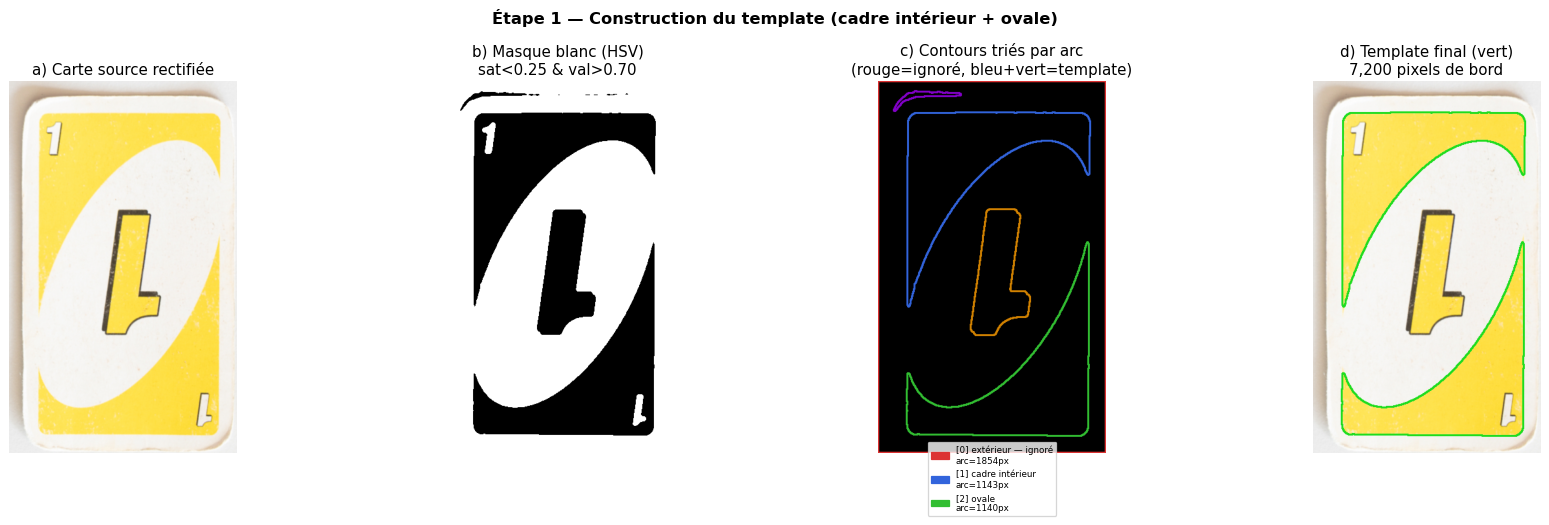

In [43]:
# ── Reconstruction du masque blanc de la carte source pour la visualisation ──
img_f     = source_card.astype(np.float32) / 255.0
hsv_card  = rgb2hsv(img_f)
white_bin = (gaussian_filter(
    ((hsv_card[:,:,1] < 0.25) & (hsv_card[:,:,2] > 0.70)).astype(np.float32),
    sigma=2) > 0.5).astype(np.uint8) * 255

# Contours triés, colorés
all_cnts, _ = cv2.findContours(white_bin, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
sorted_cnts = sorted(all_cnts, key=lambda c: cv2.arcLength(c, True), reverse=True)
COLORS  = [(220,50,50),(50,100,220),(50,190,50),(210,130,0),(130,0,200)]
LABELS  = ['[0] extérieur — ignoré','[1] cadre intérieur','[2] ovale','[3]','[4]']

color_img = np.zeros((CARD_H, CARD_W, 3), dtype=np.uint8)
for i, cnt in enumerate(sorted_cnts[:5]):
    cv2.drawContours(color_img, [cnt], -1, COLORS[i], 2)

overlay = source_card.copy()
overlay[template > 0] = [30, 220, 30]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
axes[0].imshow(source_card)
axes[0].set_title('a) Carte source rectifiée')
axes[0].axis('off')

axes[1].imshow(white_bin, cmap='gray')
axes[1].set_title('b) Masque blanc (HSV)\nsat<0.25 & val>0.70')
axes[1].axis('off')

patches = [mpatches.Patch(color=np.array(COLORS[i])/255,
           label=f'{LABELS[i]}\narc={cv2.arcLength(sorted_cnts[i],True):.0f}px')
           for i in range(min(3, len(sorted_cnts)))]
axes[2].imshow(color_img)
axes[2].set_title('c) Contours triés par arc\n(rouge=ignoré, bleu+vert=template)')
axes[2].legend(handles=patches, loc='lower center', fontsize=7,
               bbox_to_anchor=(0.5,-0.18))
axes[2].axis('off')

axes[3].imshow(overlay)
axes[3].set_title(f'd) Template final (vert)\n{(template>0).sum():,} pixels de bord')
axes[3].axis('off')

plt.suptitle('Étape 1 — Construction du template (cadre intérieur + ovale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Étape 2 — Masque de blobs

**Objectif :** isoler chaque groupe de cartes dans l'image de test.

**Méthode :**
1. **Segmentation HSV** (`segment_cards`) : garder les pixels brillants non-gris.
2. **Nettoyage morphologique** (`clean_mask`) : fermeture (r=60, comble les trous) + ouverture (r=5, supprime le bruit).
3. **Classification** (`classify_blobs`) : solo (≈ 1 carte), multi (plusieurs cartes), token.

In [44]:
IMG_PATH = "data/train_images/L1000836.jpg"
img_rgb  = np.array(plt.imread(IMG_PATH))
H, W     = img_rgb.shape[:2]
print(f'Image : {IMG_PATH}  —  {W}×{H} px')

Image : data/train_images/L1000836.jpg  —  4000×2662 px


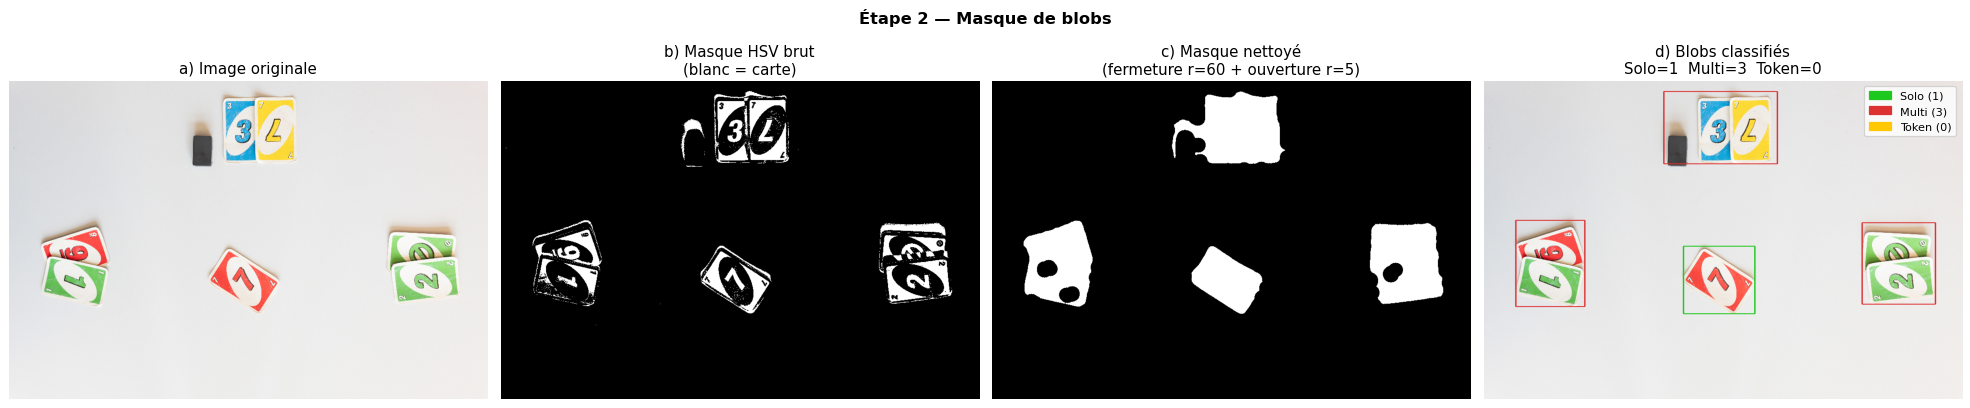

Solo : 1  Multi : 3  Token : 0
  blob label=1  aire=377,392.0  ~ 1.9 cartes
  blob label=2  aire=279,368.0  ~ 1.4 cartes
  blob label=3  aire=328,384.0  ~ 1.6 cartes


In [45]:
# ── a) Segmentation HSV ───────────────────────────────────────────────────────
mask = segment_cards(img_rgb)

# ── b) Nettoyage morphologique ────────────────────────────────────────────────
cleaned = clean_mask(mask, close_radius=60, open_radius=5, min_blob_size=5000)

# ── c) Blobs labellisés + classification ──────────────────────────────────────
labeled_full = label(cleaned)
_, solo, multi, tokens = classify_blobs(cleaned, SINGLE_AREA)

# ── Visualisation ─────────────────────────────────────────────────────────────
S = 4  # sous-échantillonnage pour l'affichage
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(img_rgb[::S,::S])
axes[0].set_title('a) Image originale'); axes[0].axis('off')

axes[1].imshow(mask[::S,::S], cmap='gray')
axes[1].set_title('b) Masque HSV brut\n(blanc = carte)'); axes[1].axis('off')

axes[2].imshow(cleaned[::S,::S], cmap='gray')
axes[2].set_title('c) Masque nettoyé\n(fermeture r=60 + ouverture r=5)'); axes[2].axis('off')

vis = img_rgb.copy()
for b in solo:
    mr,mc,Mr,Mc = b.bbox
    cv2.rectangle(vis,(mc,mr),(Mc,Mr),(30,200,30),8)
for b in multi:
    mr,mc,Mr,Mc = b.bbox
    cv2.rectangle(vis,(mc,mr),(Mc,Mr),(220,50,50),8)
for b in tokens:
    mr,mc,Mr,Mc = b.bbox
    cv2.rectangle(vis,(mc,mr),(Mc,Mr),(255,200,0),8)
axes[3].imshow(vis[::S,::S])
axes[3].legend(handles=[
    mpatches.Patch(color='#1EC81E', label=f'Solo ({len(solo)})'),
    mpatches.Patch(color='#DC3232', label=f'Multi ({len(multi)})'),
    mpatches.Patch(color='#FFC800', label=f'Token ({len(tokens)})')
], fontsize=9)
axes[3].set_title(f'd) Blobs classifiés\nSolo={len(solo)}  Multi={len(multi)}  Token={len(tokens)}')
axes[3].axis('off')

plt.suptitle('Étape 2 — Masque de blobs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Solo : {len(solo)}  Multi : {len(multi)}  Token : {len(tokens)}')
for b in multi:
    print(f'  blob label={b.label}  aire={b.area:,}  ~ {b.area/SINGLE_AREA:.1f} cartes')

---
## Étape 3 — Extraction des features blanches

**Objectif :** obtenir une image de bords qui met en évidence les mêmes structures que le template (cadre + ovale) dans chaque blob.

**Méthode (`extract_white_features`) :**
1. Rogner l'image autour du blob (+ marge de 40% de la grande dimension de la carte).
2. Seuiller en HSV : garder les pixels à faible saturation et forte valeur → **masque blanc**.
3. Lisser (Gaussian σ=2) pour éliminer le bruit sel-et-poivre.
4. Extraire les contours avec `RETR_LIST` (capture à la fois le cadre extérieur et le bord de l'ovale).
5. Dessiner les contours (épaisseur 2) → **image de bords** (feature_img).

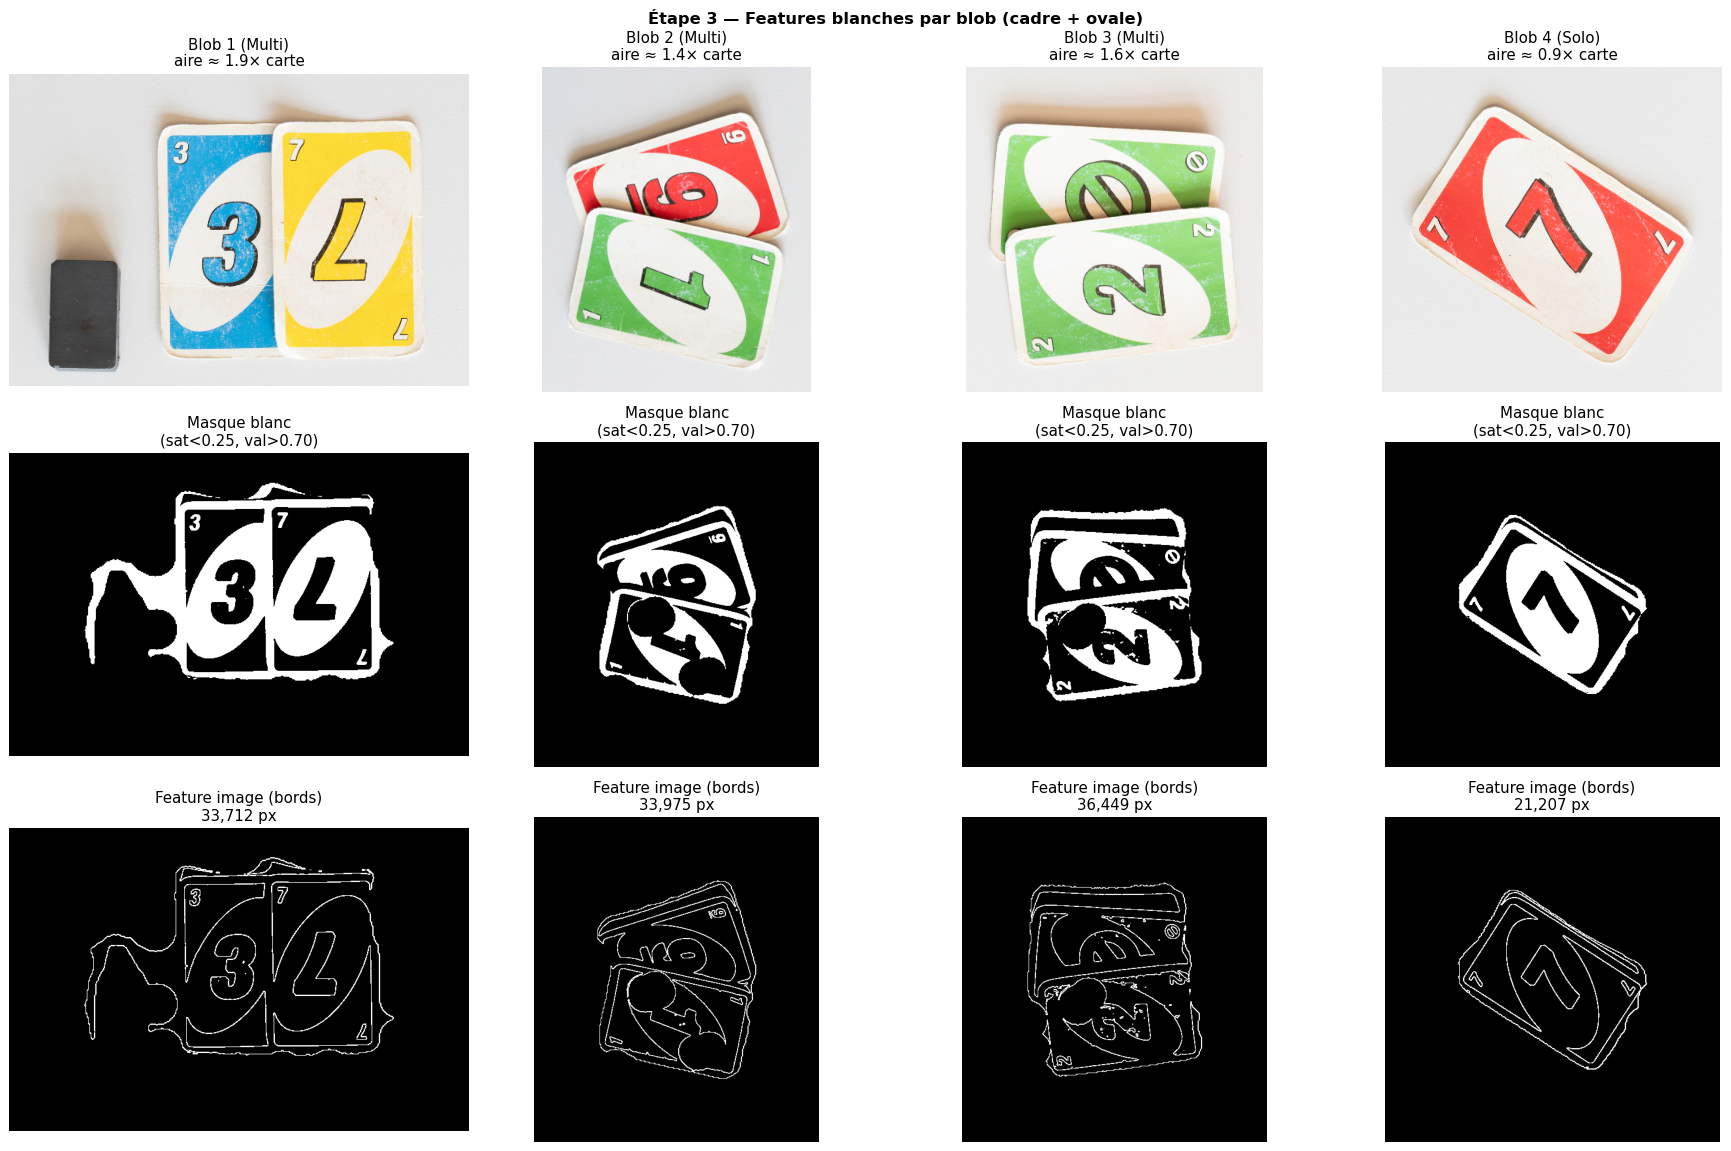

In [46]:
blobs_all = multi + solo
n_blobs   = len(blobs_all)

fig, axes = plt.subplots(3, n_blobs, figsize=(5*n_blobs, 13), squeeze=False)

features_cache = []
for j, blob in enumerate(blobs_all):
    feat, white_mask, (ox, oy) = extract_white_features(
        blob, img_rgb, labeled_full, (H, W))
    features_cache.append((feat, white_mask, ox, oy))

    # Ligne 0 : crop de l'image originale
    mr,mc,Mr,Mc = blob.bbox
    pad = 60
    r0,r1 = max(0,mr-pad),min(H,Mr+pad)
    c0,c1 = max(0,mc-pad),min(W,Mc+pad)
    lbl = 'Multi' if blob in multi else 'Solo'
    axes[0,j].imshow(img_rgb[r0:r1:2, c0:c1:2])
    axes[0,j].set_title(f'Blob {j+1} ({lbl})\naire ≈ {blob.area/SINGLE_AREA:.1f}× carte')
    axes[0,j].axis('off')

    # Ligne 1 : masque blanc
    axes[1,j].imshow(white_mask[::2,::2], cmap='gray')
    axes[1,j].set_title('Masque blanc\n(sat<0.25, val>0.70)')
    axes[1,j].axis('off')

    # Ligne 2 : image de bords
    axes[2,j].imshow(feat[::2,::2], cmap='gray')
    axes[2,j].set_title(f'Feature image (bords)\n{(feat>0).sum():,} px')
    axes[2,j].axis('off')

plt.suptitle('Étape 3 — Features blanches par blob (cadre + ovale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Étape 4 — Template matching (corrélation croisée normalisée)

**Objectif :** localiser chaque carte dans chaque blob multi-cartes.

**Méthode (`template_match_accumulate`) :**

Pour chaque angle θ ∈ [−90°, 90°] (pas de 5°) :
1. **Rotation** du template de θ° avec canvas agrandi (pas de clipping).
2. **Corrélation** `cv2.matchTemplate(feature_img, rotated_tmpl, TM_CCORR_NORMED)` → score ∈ [0, 1] à chaque position.
3. **Placement** : le score est mis à la position du **centre** du template (décalage tw/2, th/2).
4. **Mise à jour** de l'accumulateur si ce score est meilleur que le précédent.

Après tous les angles → Gaussian blur → normalisation → `find_peaks` (NMS greedy).

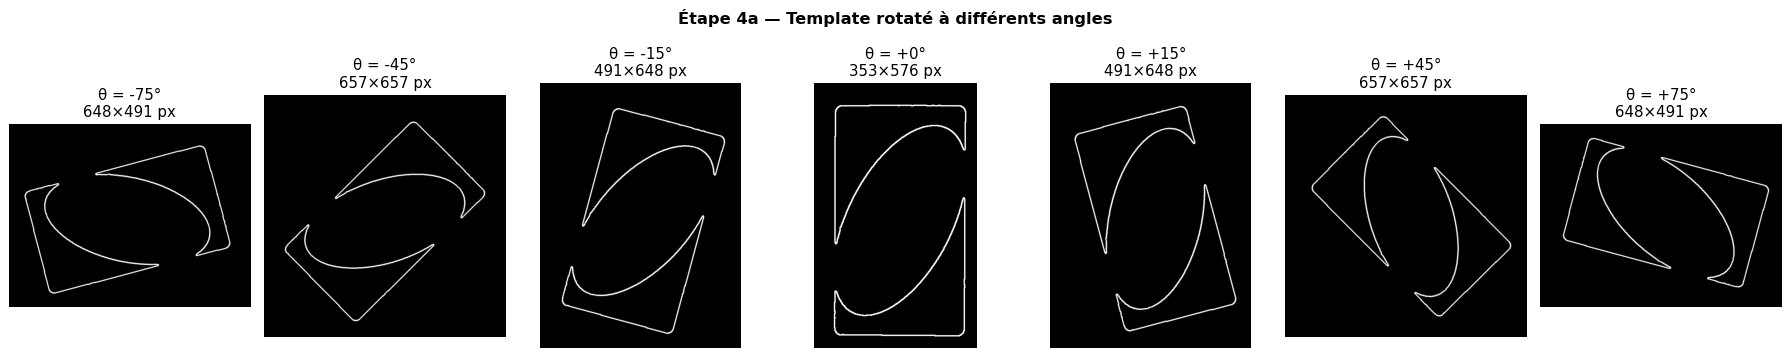

In [47]:
# ── Visualiser le template à différents angles ────────────────────────────────
test_angles = [-75, -45, -15, 0, 15, 45, 75]
fig, axes = plt.subplots(1, len(test_angles), figsize=(20, 4))
for ax, ang in zip(axes, test_angles):
    rot, (tw, th) = _rotate_template(template, ang)
    ax.imshow(rot, cmap='gray')
    ax.set_title(f'θ = {ang:+.0f}°\n{tw}×{th} px')
    ax.axis('off')
plt.suptitle('Étape 4a — Template rotaté à différents angles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

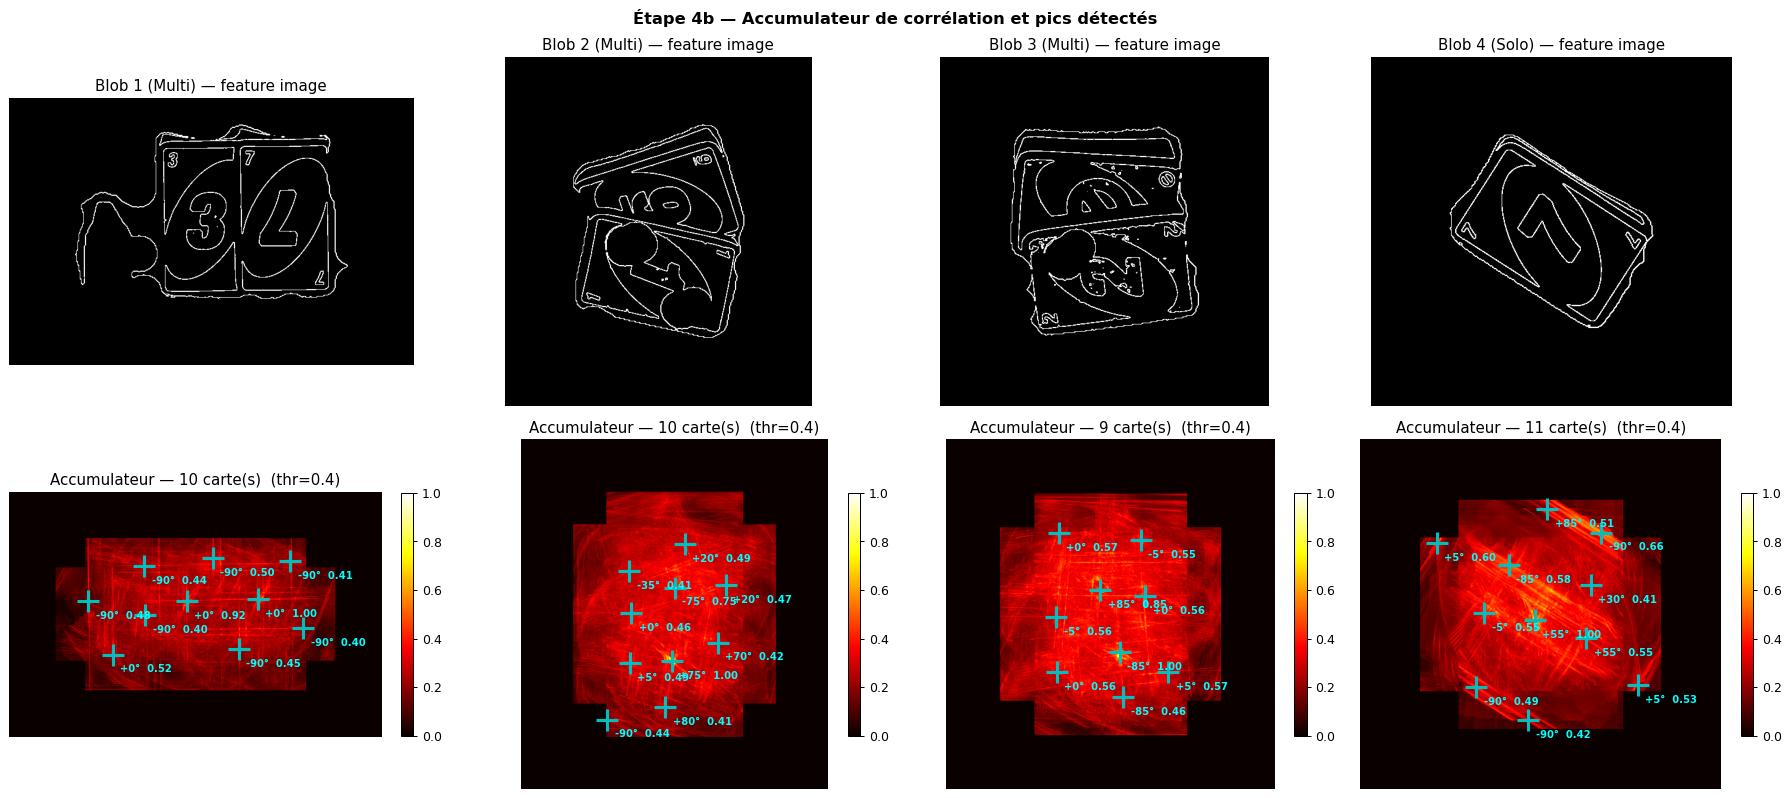

In [48]:
# ── Accumulateur et pics pour chaque blob ────────────────────────────────────
THRESHOLD  = 0.4
angles_deg = np.linspace(-90, 90, 36, endpoint=False).tolist()
n_blobs    = len(blobs_all)

fig, axes = plt.subplots(2, n_blobs, figsize=(5*n_blobs, 9), squeeze=False)

for j, (blob, (feat, white_mask, ox, oy)) in enumerate(zip(blobs_all, features_cache)):
    acc, angle_map, sw_map, sh_map = template_match_accumulate(
        feat, template, angles_deg, scales=[1.0])

    peaks = find_peaks(acc, angle_map, CARD_W, CARD_H, threshold=THRESHOLD)

    # Ligne 0 : feature image
    axes[0,j].imshow(feat[::2,::2], cmap='gray')
    lbl = 'Multi' if blob in multi else 'Solo'
    axes[0,j].set_title(f'Blob {j+1} ({lbl}) — feature image')
    axes[0,j].axis('off')

    # Ligne 1 : accumulateur + pics
    im = axes[1,j].imshow(acc[::2,::2], cmap='hot', vmin=0, vmax=1)
    for px, py, ang, sw, sh, sc in peaks:
        axes[1,j].plot(px//2, py//2, 'c+', ms=18, mew=2.5)
        axes[1,j].annotate(f'{ang:+.0f}°  {sc:.2f}',
                           (px//2, py//2), color='cyan', fontsize=8,
                           fontweight='bold', xytext=(6, -14),
                           textcoords='offset points')
    plt.colorbar(im, ax=axes[1,j], fraction=0.03)
    axes[1,j].set_title(f'Accumulateur — {len(peaks)} carte(s)  (thr={THRESHOLD})')
    axes[1,j].axis('off')

plt.suptitle('Étape 4b — Accumulateur de corrélation et pics détectés', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Étape 5 — Résultat final

Pipeline complète sur tous les blobs via `detect_cards_in_blob(template=template)`.  
Rectangles orientés dessinés en vert, centre en rouge.

In [49]:
THRESHOLD  = 0.65
result_img = img_rgb.copy()
all_cards  = []

for blob in multi + solo:
    cards, acc, feat, (ox, oy) = detect_cards_in_blob(
        blob, labeled_full, (H, W),
        CARD_W, CARD_H,
        n_angles=36,
        img_rgb=img_rgb,
        template=template,
        threshold=THRESHOLD
    )
    all_cards.extend(cards)

print(f'Total cartes détectées : {len(all_cards)}')
for i,(cx,cy,ang,sw,sh,sc) in enumerate(all_cards):
    print(f'  Carte {i+1:2d} : centre=({cx:4d},{cy:4d})  angle={ang:+.0f}°  score={sc:.3f}')

Total cartes détectées : 8
  Carte  1 : centre=(2211, 407)  angle=+0°  score=1.000
  Carte  2 : centre=(1942, 413)  angle=+0°  score=0.922
  Carte  3 : centre=( 543,1688)  angle=+75°  score=1.000
  Carte  4 : centre=( 552,1439)  angle=-75°  score=0.749
  Carte  5 : centre=(3492,1654)  angle=-85°  score=1.000
  Carte  6 : centre=(3428,1452)  angle=+85°  score=0.848
  Carte  7 : centre=(1945,1684)  angle=+55°  score=1.000
  Carte  8 : centre=(2139,1429)  angle=-90°  score=0.662


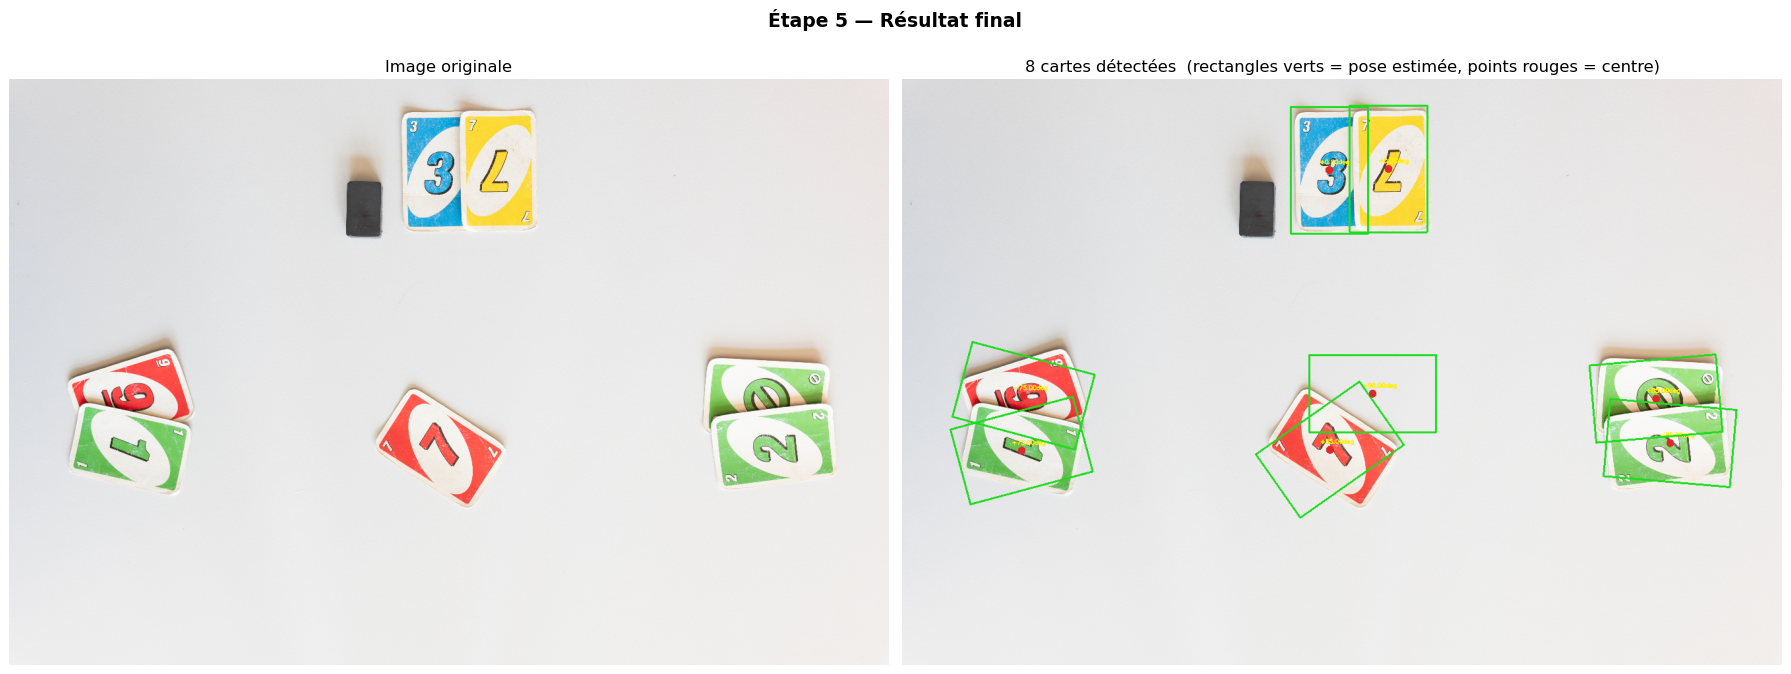

In [50]:
for cx,cy,ang,sw,sh,sc in all_cards:
    hw = int(CARD_W*sw/2);  hh = int(CARD_H*sh/2)
    corners_loc = np.array([[-hw,-hh],[hw,-hh],[hw,hh],[-hw,hh]], dtype=np.float32)
    a = np.deg2rad(ang);  ca,sa = np.cos(a),np.sin(a)
    corners = ((np.array([[ca,-sa],[sa,ca]]) @ corners_loc.T).T
               + np.array([cx,cy])).astype(np.int32)
    cv2.polylines(result_img, [corners], True, (30,220,30), 8)
    cv2.circle(result_img, (cx,cy), 18, (220,40,40), -1)
    cv2.putText(result_img, f'{ang:+.2f}deg', (cx-45,cy-28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,240,0), 3)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(img_rgb[::3,::3])
axes[0].set_title('Image originale', fontsize=13)
axes[0].axis('off')
axes[1].imshow(result_img[::3,::3])
axes[1].set_title(
    f'{len(all_cards)} cartes détectées  '
    f'(rectangles verts = pose estimée, points rouges = centre)', fontsize=13)
axes[1].axis('off')
plt.suptitle('Étape 5 — Résultat final', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()